In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def find_向上级反映_rule_base(docs):
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # Define the keywords pattern
    keywords_章节 = ["(请径向|请向|向).*?(反映|反馈|报告|通报)"]
    pattern = re.compile('|'.join(keywords_章节))
    
    # Process the document to separate it into paragraphs
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    
    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        match = pattern.search(paragraph)
        if match:
            # Append the stripped paragraph and the match found
            matched_paragraphs.append((paragraph.strip(), match.group()))
    
    # Second loop: Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
    
    return matched_paragraphs, matched_paragraphs_index


## Demonstration for using find_向上级反映_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[10]
docs = open(f'sample/{file_sample}', 'r').read()
matched_paragraphs, matched_paragraphs_index = find_向上级反映_rule_base(docs)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [5]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason
0,对于有关地方和部门以“红头文件”设置行政许可，限制市场竞争，以及违法实施行业保护和地区封锁，并拒不纠正的，将专题向省政府报告,向省政府报告


$\textbf{We can also check where is the sentence}$

In [6]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.1168162
原文链接：https://www.pkulaw.com/lar/af7a561a844ac02328491e6ea63ffe9cbdfb.html
贵州省发展和改革委员会、贵州省人民政府法制办公室关于开展清理和规范招标投标有关规定的通知

贵州省发展和改革委员会、贵州省人民政府法制办公室关于开展清理和规范招标投标有关规定的通知

（黔发改法规[2016]292号）

各市、自治州人民政府，贵安新区管委会，省人民政府有关部门、直属机构，仁怀市人民政府，威宁县人民政府：

　　为贯彻落实国家发展改革委等7部委《关于建立清理和规范招标投标有关规定长效机制的意见》（发改法规〔2015〕787号，以下简称《意见》）和《关于进一步做好清理和规范招标投标有关规定长效机制贯彻实施工作的通知》（发改办法规〔2015〕3485号），促进招标投标市场健康有序发展，维护公平竞争的市场秩序，按照省政府要求，现就全省开展清理和规范招标投标有关规定有关事项通知如下：
　　一、清理范围

　　现行有效的招标投标政府规章；全省各级政府、政府组成部门及法律法规授权组织发布的招标投标规范性文件。
　　二、清理标准

　　清理工作按照下列标准进行：

　　1.招标投标政府规章、规范性文件违反招标投标等法律法规规定；

　　2.招标投标政府规章、规范性文件存在违法设置行政审批、备案、收费等限制市场主体合法权利，加重市场主体负担，违规干预市场主体自主权等规定；

　　3.招标投标政府规章、规范性文件存在妨碍市场公平竞争，适用期已过、调整对象不存在等不适应经济社会发展需要的情况。
　　三、清理原则和方法

　　本次清理按照“谁制定谁清理、谁起草谁负责，两个以上部门联合起草的由牵头部门负责”的原则，“至下而上、逐级审查、目录管理”的方法组织开展。
　　四、清理程序及时限

　　（一）全面清理

　　请各级各部门按照“谁制定谁清理、谁起草谁负责，两个以上部门联合起草的由牵头部门负责”的原则，对本部门起草制定的或以本部门文号印发的或代政府起草的招标投标规章、规范性文件进行全面清理，提出“保留”、“修改”、“废止”或者“宣布失效”的清理意见，并将相关文件录入《贵州省清理和规范招标投标有关规定情况表》（以下简称《清理情况表》），随同相关文件文本及电子文档各1份报送同级

## Now we can run batch processing on our sample data ##

In [7]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['File Name', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        matched_paragraphs, matched_paragraphs_index = find_向上级反映_rule_base(docs)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list)]
    
    return return_df


In [8]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length
0,吉林保监局关于安邦人寿保险股份有限公司吉林...(FBM-CLI.12.1776690).txt,三、筹建工作完成后，你公司应按有关规定及时向吉林保监局提交开业验收报告，经批准后方可开业,向吉林保监局提交开业验收报告,485,44
1,北京市人民政府办公厅印发《关于在“十三五”...(FBM-CLI.12.1250419).txt,,,4421,0
2,山西省林业和草原局关于印发《退耕还林还草作...(FBM-CLI.12.4108330).txt,,,805,0
3,北京市教育委员会、北京市经济和信息化局、北...(FBM-CLI.12.4087809).txt,,,480,0
4,吕梁市住房保障和城乡建设管理局关于转发山西...(FBM-CLI.12.1887683).txt,,,499,0


$\textbf{Here we provide some statistics on the results}$

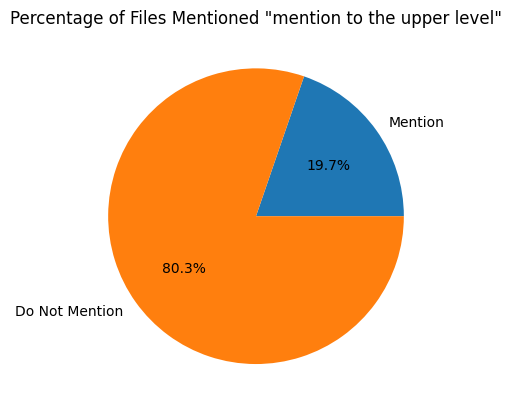

In [9]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "mention to the upper level"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

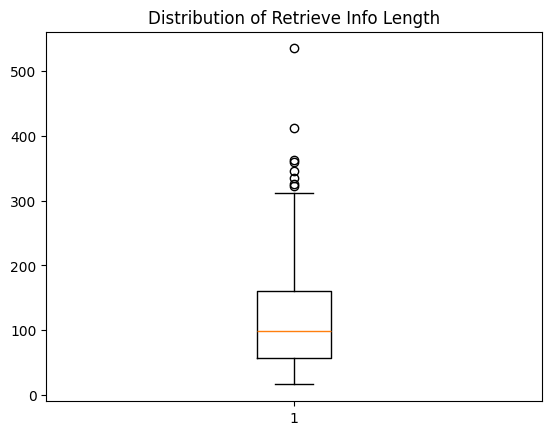

In [10]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

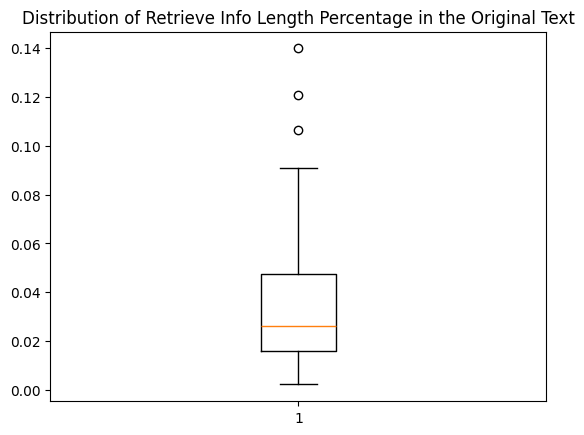

In [11]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [12]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
345,鸡西市人民政府办公室关于进一步加强基本养老...(FBM-CLI.12.800136).txt,地税部门主要负责组织税费比对工作及向社保经办机构提供应参保未参保企业名单并据实征收；发挥税务稽查优势，对正常纳税但未参保企业进行调查核实，下达《限期参保通知单》，向社保经办机构提供未参保企业信息，督促企业及时办理参保、缴费登记并及时足额缴费；依法对已参保但未缴费或者长期欠费企业加大清缴力度，努力做到应收尽收；依法对逾期不缴纳社会保险费的用人单位，从缴费单位开户银行或者其他金融机构直接划拨，或者申请法院扣押、查封、拍卖其等价资产抵缴养老保险费；加强信息沟通，及时向相关部门通报征缴工作进展情况；对预算编制、执行及社保费发放工作进行监督\n工商部门主要负责向地税、人社等部门提供内外资私营企业和个体工商户等用人单位工商登记情况、营业执照年审情况、办理变更、注销、登记情况，并将情况定期通报地税、人社等部门，督促用人单位及时参保缴费\n招投标机构负责向人社、地税部门提供招投标单位情况，在工程建设招投标时，审查施工项目经理、技术负责人、工长、安检人员参保缴费情况，并将招投标单位员工参保情况及时通报给地税和人社部门\n煤管部门负责向人社、地税部门提供开工企业情况，在煤炭企业开工验收时，审查企业参保缴费情况，并将开工企业参保情况及时通报给地税和人社部门，督促其为员工办理参保缴费,向社保经办机构提供应参保未参保企业名单并据实征收；发挥税务稽查优势，对正常纳税但未参保企业进行调查核实，下达《限期参保通知单》，向社保经办机构提供未参保企业信息，督促企业及时办理参保、缴费登记并及时足额缴费；依法对已参保但未缴费或者长期欠费企业加大清缴力度，努力做到应收尽收；依法对逾期不缴纳社会保险费的用人单位，从缴费单位开户银行或者其他金融机构直接划拨，或者申请法院扣押、查封、拍卖其等价资产抵缴养老保险费；加强信息沟通，及时向相关部门通报\n向地税、人社等部门提供内外资私营企业和个体工商户等用人单位工商登记情况、营业执照年审情况、办理变更、注销、登记情况，并将情况定期通报\n向人社、地税部门提供招投标单位情况，在工程建设招投标时，审查施工项目经理、技术负责人、工长、安检人员参保缴费情况，并将招投标单位员工参保情况及时通报\n向人社、地税部门提供开工企业情况，在煤炭企业开工验收时，审查企业参保缴费情况，并将开工企业参保情况及时通报,6435,535,0.083139
94,阳江市人民政府关于印发《阳江市人民政府工作...(FBM-CLI.12.5113114).txt,三十三、市政府要自觉接受市人大及其常委会的监督，认真负责地报告工作，接受询问和质询，依法将市政府规章和规范性文件报送备案，落实重大决策出台前向市人大常委会报告制度；自觉接受市政协的民主监督，虚心听取意见和建议\n对监督中发现的问题，要认真整改并向市政府报告\n四十四、市政府全体会议和市政府常务会议的纪要，由市府办公室起草，按程序报市长签发；会议讨论决定的事项中，需要办理的，由市府办公室按工作性质向主办单位发出交办通知，并负责催办，加强会议决定事项督办力度，定期将落实情况向市政府领导同志报告\n市长离市出访、出差、休假、学习，应报市委主要负责同志审批同意后，由市府办公室按规定向省委办公厅（值班室）、省政府办公厅报备，副市长、秘书长离市出访、出差、休假、学习，应事先报告市长同意，由市府办公室向市委办公室报备\n五十五、市政府各部门发布涉及政府重要工作部署、经济社会发展重要问题的信息，要经过严格审定，重大情况要及时向市政府报告,向市人大常委会报告\n向市政府报告\n向主办单位发出交办通知，并负责催办，加强会议决定事项督办力度，定期将落实情况向市政府领导同志报告\n向省委办公厅（值班室）、省政府办公厅报备，副市长、秘书长离市出访、出差、休假、学习，应事先报告\n向市政府报告,9957,412,0.041378
360,北京市法学会关于印发《北京市法学会研究会、...(FBM-CLI.12.1201493).txt,(一)由三名(含三名)以上的学科带头人或专家发起，组成筹备组，向市法学会提交申请报告、研究会组织规则(章程)草案和会长、副会长、秘书长、理事候选人建议名单\n第三十七条 研究会变更名称、领导成员、办公住所等，应及时向北京市法学会报告\n下列重大事项应事先向北京市法学会报告：\n(四)联系研究会、社团法学会及广大会员，为其自身建设和发展提供各种服务，加强对研究会、社团法学会发起、成立、换届、社团登记及年检各环节的帮助与指导，定期向研究会、社团法学会寄送《法学杂志》、《北京市法学会》工作刊、《首都法学动态》、《研究组织工作动态》等相关资料，不定期举办相关培训、讲座和报告会，召开研究组织建设工作会、秘书长联席会议等活动，不断提升研究会、社团法学会的工作水平和自身发展\n(二)北京市法学会资助的课题费，应向北京市法学会报告使用情况；,向市法学会提交申请报告\n向北京市法学会报告\n向北京市法学会报告\n向研究会、社团法学会寄送《法学杂志》、《北京市法学会》工作刊、《首都法学动态》、《研究组织工作动态》等相关资料，不定期举办相关培训、讲座和报告\n向北京市法学会报告,7141,363,0.050833


In [13]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
409,广西壮族自治区物价局转发国家发展改革委关于...(FBM-CLI.12.1093862).txt,请各市价格主管部门及中石化广西石油分公司、中石油广西销售分公司密切关注成品油市场动态情况，如有异常情况，请及时向自治区物价局报告（联系人：刘江 传真电话：0771-5829617；电子邮箱：spjgc2008@163.com）,向自治区物价局报告,808,113,0.139851
82,山西省民政厅关于公开新冠肺炎疫情防控捐赠款...(FBM-CLI.12.1568388).txt,为推动全省慈善力量更好发挥作用，坚决打赢疫情防控攻坚战，根据《中华人民共和国慈善法》相关规定和民政部要求，现向社会公开新冠肺炎疫情防控捐赠款物管理使用问题投诉举报受理电话，欢迎广大群众如实反映有关情况,向社会公开新冠肺炎疫情防控捐赠款物管理使用问题投诉举报受理电话，欢迎广大群众如实反映,827,100,0.120919
408,中共郑州市档案局委员会关于印发《郑州市档案...(FBM-CLI.12.3877980).txt,"向上级党组织和纪检监察机构报告时，应当将本局领导人员执行“三重一大""决策制度情况作为重点内容，坚持进行年度检查考核，及时发现并纠正决策中存在的问题，并提出修改和完善有关制度的意见和建议\n对未经领导班子集体决策就实施的“三重一大""事项，有关部门和人员知情后应及时向上级党委、纪委等部门报告\n一是党政主要负责人要经常沟通，相互提醒，做到既相互支持，又相互制约；二是班子成员应根据分工和职责及时向领导班子报告“三重一大""事项决策的执行情况；三是领导班子成员在民主生活会、述职述廉时，要把“三重一大""决策制度执行情况作为重要内容之一；四是领导班子成员相互监督，对违反“三重一大""决策制度的行为，有责任予以劝阻，劝阻无效时须向班子主要领导或上级报告；五是充分发挥同级纪委的监督作用",向上级党组织和纪检监察机构报告\n向上级党委、纪委等部门报告\n向领导班子报告,3150,335,0.106349


## We can also comparing the statistics results between two different labels ##

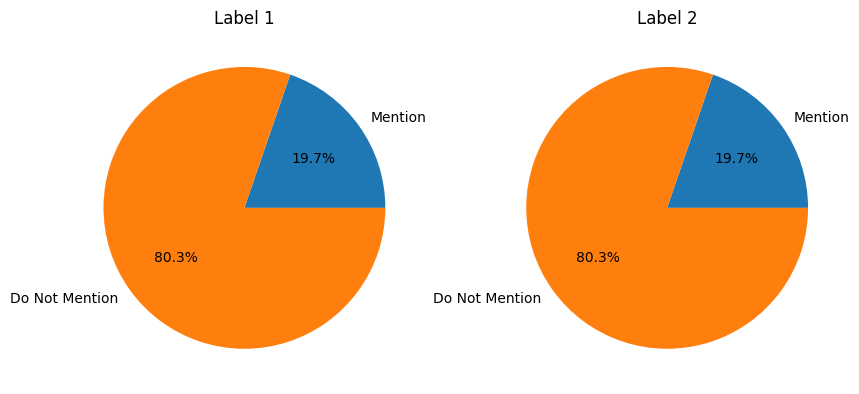

In [14]:
# To achieve this comparison, we need to folder to store the policy data for two labels respectively
# To avoid the relative path issue, We use absolute path here
path_to_folder_label1 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'
path_to_folder_label2 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'

df_label1 = run_batch(path_to_folder_label1)
df_label2 = run_batch(path_to_folder_label2)

# compare two bar chart
is_mention_label1 = len(df_label1[df_label1['Retrieve Info'] != ''])
do_not_mention_label1 = len(df_label1[df_label1['Retrieve Info'] == ''])
is_mention_label2 = len(df_label2[df_label2['Retrieve Info'] != ''])
do_not_mention_label2 = len(df_label2[df_label2['Retrieve Info'] == ''])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].pie([is_mention_label1, do_not_mention_label1], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[0].set_title('Label 1')
ax[1].pie([is_mention_label2, do_not_mention_label2], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[1].set_title('Label 2')
plt.show()

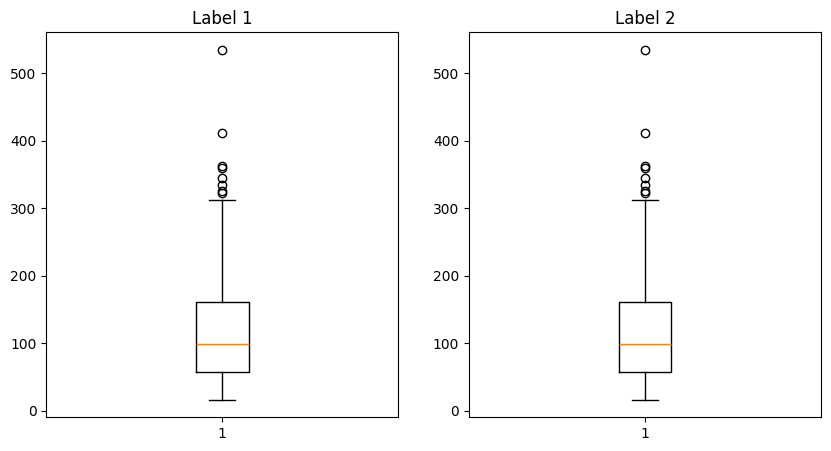

In [15]:
# We can also compare the distribution of retrieve info length
df_label1 = df_label1[df_label1['Retrieve Info'] != '']
df_label2 = df_label2[df_label2['Retrieve Info'] != '']

retrieve_info_length_label1 = df_label1['Retrieve Info'].apply(lambda x: len(x))
retrieve_info_length_label2 = df_label2['Retrieve Info'].apply(lambda x: len(x))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(retrieve_info_length_label1)
ax[0].set_title('Label 1')
ax[1].boxplot(retrieve_info_length_label2)
ax[1].set_title('Label 2')
plt.show()

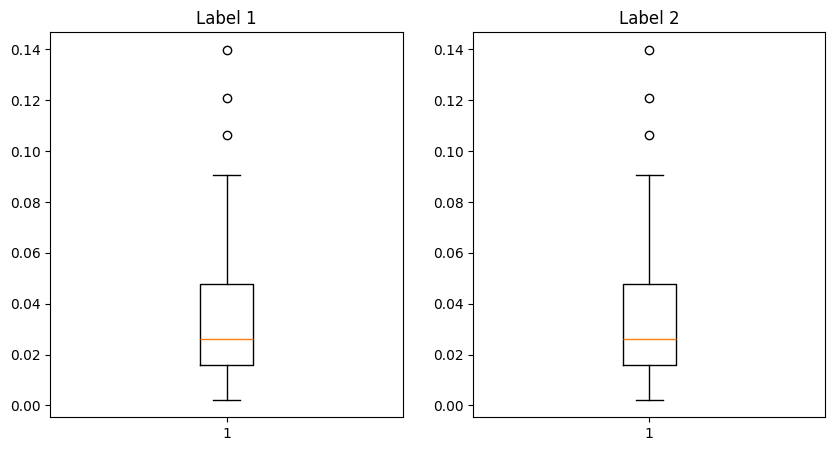

In [16]:
df_label1['Retrieve Info Length Percentage'] = df_label1['Retrieve Info Length'] / df_label1['Original Text Length']
df_label2['Retrieve Info Length Percentage'] = df_label2['Retrieve Info Length'] / df_label2['Original Text Length']

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(df_label1['Retrieve Info Length Percentage'])
ax[0].set_title('Label 1')
ax[1].boxplot(df_label2['Retrieve Info Length Percentage'])
ax[1].set_title('Label 2')
plt.show()